In [6]:
import torch, torchvision, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

#  transforms:  3×32×32 RGB  →  flat 3072-vector in [0,1]
to_flat = T.Compose([
    T.ToTensor(),                       # [3,32,32], float32 ∈ [0,1]
    T.Lambda(lambda x: x.view(-1))      # flatten to [3072]
])

# full CIFAR-10 training set  (50 000 images)
cifar10 = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=to_flat
)

train_frac  = 0.90
total       = len(cifar10)                    # 50 000
train_size  = int(total * train_frac)
torch.manual_seed(0)                          # seed
rdid        = torch.randperm(total)
train_idx   = rdid[:train_size]
test_idx    = rdid[train_size:]
cifar10_train = Subset(cifar10, train_idx)
cifar10_test  = Subset(cifar10, test_idx)

# feature dimension   (used later by model)
D = 3 * 32 * 32     # 3072

Files already downloaded and verified


In [7]:
import torch, torch.nn as nn, torch.nn.functional as F

### Training Transformer Implementation


class WitnessScoreCrossAttention(nn.Module):
    """
    ∇ log q_t(x) for a batch of B items, each with C query vectors.
    Shapes
    -------
      x : [B, C, D]
      W : [K, D]   (learnable witnesses, fp32 parameter)
      t : scalar  or  [B, C] tensor   (broadcastable to [B, C, 1])
      return  score : [B, C, D]
    """
    def __init__(self, init_W: torch.Tensor):          # init_W float32 [K,D]
        super().__init__()
        

    
    @staticmethod
    def _pairwise_scores(x, tx, kernel='std'):
        """
        Exact KDE score where keys == values == queries (self-attention).
        x : [B,C,D]   t : broadcastable to [B,C,1]
        returns score_self : [B,C,D]
        """
        # different tx for context and for query
        C = x.shape[1]
        # squared norms
        x2 = (x**2).sum(-1, keepdim=True)           # [B,C,1]
        # pairwise dot-products   -> [B,C,C]
        dot = torch.matmul(x, x.transpose(-1, -2))
        # pairwise squared distances
        dist2 = - 2*dot    # [B,C,C]
        if kernel=='rbf':
            dist2 = dist2 + x2 + x2.transpose(-2, -1) 
        w = torch.softmax(-0.5 * dist2 / tx[None,:,None], dim=-1) # [B,C,C]
        expX = torch.matmul(w, x)                   # [B,C,D]

        return -(x - expX) / tx[None,:,None]                      # [B,C,D]

    def forward(self, x, tW, tx, kernel='std'):
        B, C, D = x.shape
        assert (tW.dim() == 1)
        assert tx.dim() == 1 and tx.shape[0]==C, tx.shape

        x_score = self._pairwise_scores(x, tx, kernel)
        return (None, x_score)

def init_witnesses(train_tensor: torch.Tensor,
                   K: int = 1000,
                   seed: int | None = None) -> torch.Tensor:
    """
    Initialise K witness vectors by sampling K distinct examples
    from the dataset (no replacement).

    Args
    ----
    train_tensor : [N, D] float32 – flattened training images
    K            : number of witnesses
    seed         : optional RNG seed for reproducibility

    Returns
    -------
    W0 : [K, D] float32  (clone of the selected rows)
    """
    if seed is not None:
        torch.manual_seed(seed)

    N = train_tensor.size(0)
    if K > N:
        raise ValueError(f"K={K} exceeds dataset size N={N}")

    # sample K unique indices without replacement
    idx = torch.randperm(N, device=train_tensor.device)[:K]

    # gather the corresponding data points
    W0 = train_tensor[idx].clone()          # [K, D]
    return W0.float()                       # ensure fp32



class LStepDenoiser_multiple(nn.Module):
    def __init__(self, L, K, train_tensor, t_start=1.0, t_end=0.1, kernel='std'):
        super().__init__()

        # six independent witness layers
        self.scores = nn.ModuleList([
            WitnessScoreCrossAttention(None)
            for i in range(L)
        ])
        self.kernel=kernel
        
        #  schedule parameters 
        t_lin  = torch.linspace(t_start, t_end, L)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:]-t_lin[-2:-1]])/2
        self.tW_raw  = nn.Parameter(torch.log(torch.exp(t_lin)  - 1)[:,None].repeat((1,2)).detach())
        self.dtW_raw = nn.Parameter(torch.log(torch.exp(-dt_lin) - 1)[:,None].repeat((1,2)).detach())
            
        self.tx_raw  = nn.Parameter(torch.log(torch.exp(t_lin).detach()  - 1)[:,None].repeat((1,2)).detach())
        self.dtx_raw = nn.Parameter(torch.log(torch.exp(-dt_lin).detach() - 1)[:,None].repeat((1,2)).detach())

        self.do_ICL = True

    def times_and_steps(self):
        tW  = F.softplus(self.tW_raw)
        dtW = -F.softplus(self.dtW_raw)
        tx  = F.softplus(self.tx_raw)
        dtx = -F.softplus(self.dtx_raw)
        return tW, dtW, tx, dtx

    def forward(self, x0):
        tW, dtW, tx, dtx = self.times_and_steps()
        C = x0.shape[1]
        x = x0; traj=[x.clone()]
        L = len(self.scores)
        for i in range(L):
            dtW_vec = torch.cat((dtW[i,0].repeat(C-1), dtW[i,1].repeat(1))).to(device)
            tW_vec = torch.cat((tW[i,0].repeat(C-1), tW[i,1].repeat(1))).to(device)
            dtx_vec = torch.cat((dtx[i,0].repeat(C-1), dtx[i,1].repeat(1))).to(device)
            tx_vec = torch.cat((tx[i,0].repeat(C-1), tx[i,1].repeat(1))).to(device)

            W_score, x_score = self.scores[i](x, tW_vec, tx_vec, self.kernel)       # layer-specific witnesses
            
            if self.do_ICL:
                x = x - tx_vec[None,:,None] * dtx_vec[None,:,None] * x_score
            traj.append(x.clone())
        return x, traj

In [3]:
#MNIST   context setup
# It re-loads MNIST, builds a “context” tensor
# with C noisy views of the same class, and plugs it into the same witness
# architecture. 
from torch.utils.data import TensorDataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'


# 1.  dataset   (flat 28×28 → 784)

flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])

D       = 28 * 28
C       = 4          # context size  (4 noisy views of one digit)
BATCH   = 5000
N_CONTEXT = 100
NOISE_STD = 0.3

In [4]:
Layers = 6
epochs    = 1
mnist = torchvision.datasets.MNIST('./data', train=True, download=True, transform=flat)
class_id = 3
indices = [i for i, (_, y) in enumerate(mnist) if y == class_id]
mnist_single_class = Subset(mnist, indices)
all_data = []
all_labels = []
for x, y in mnist_single_class:
    all_data.append(x.to(device))
    all_labels.append(torch.tensor(y, device=device))
data_tensor = torch.stack(all_data)     # [N, 784]
label_tensor = torch.tensor(all_labels) # [N]
# Wrap in a TensorDataset
dataset_on_device = TensorDataset(data_tensor, label_tensor)
n_total = len(dataset_on_device)
n_train = int(0.9 * n_total)
n_test = n_total - n_train
generator = torch.Generator().manual_seed(42)
train_dataset, test_dataset = random_split(dataset_on_device, [n_train, n_test], generator=generator)
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH//10, shuffle=True, drop_last=True)


K_WIT = 1000
model = LStepDenoiser_multiple(
    L=Layers, K=K_WIT, train_tensor=None, t_start=10, t_end=5, kernel='rbf').to(device)

optim     = torch.optim.Adam(model.parameters(), lr=1e-1, betas=(0.9,0.9))
scaler    = torch.cuda.amp.GradScaler()
steps_per_epoch = len(all_data)//BATCH
total_steps     = epochs * steps_per_epoch
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optim, T_max=total_steps, eta_min=1e-3)



Epoch 1/50  –  train MSE ≈ 7.0312e+01
Per-layer RMSE: ['8.4009', '8.3420', '8.3217', '8.3174', '8.3173', '8.3173', '8.3173']


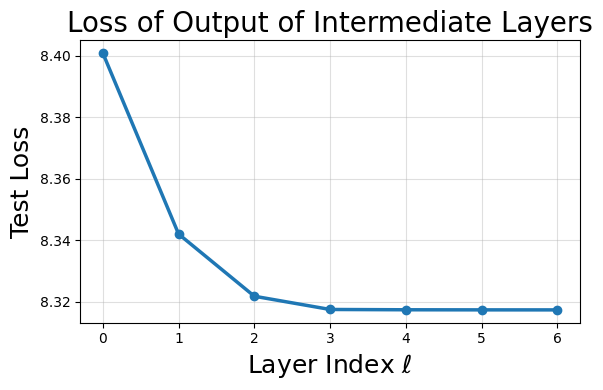

3887

In [5]:
### All-digits, single-model, per-layer RMSE
"""
Train ONE 6-layer RBF model on the full MNIST training set (IID over all
digits) and plot the RMSE after each intermediate output.

"""

import math, matplotlib.pyplot as plt, numpy as np, gc
from torch.utils.data import DataLoader, random_split, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

#  hyper-parameters 
LAYERS_FIXED_ALL       = 6
EPOCHS_ALL             = 2000
LR_ALL                 = 1e-3
CONTEXT_ALL            = 100          
GROUPS_PER_BATCH_ALL   = 10
BATCH_ALL              = CONTEXT_ALL * GROUPS_PER_BATCH_ALL
NOISE_STD_RUN          = .3 
DEVICE_ALL             = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert 'flat' in globals(), "Run earlier data-prep cells first."

#  full MNIST 90/10 split 
mnist_full = torchvision.datasets.MNIST("./data", train=True,
                                        download=True, transform=flat)
X_full = torch.stack([d[0] for d in mnist_full])          # [60 000, 784]
Y_full = torch.tensor([d[1] for d in mnist_full])
mnist_ds = TensorDataset(X_full, Y_full)

n_tot  = len(mnist_ds)
n_tr   = int(0.9 * n_tot)
train_set_all, test_set_all = random_split(
    mnist_ds, [n_tr, n_tot - n_tr],
    generator=torch.Generator().manual_seed(0)
)

train_loader_all = DataLoader(train_set_all, batch_size=BATCH_ALL,
                              shuffle=True,  drop_last=True)
test_loader_all  = DataLoader(test_set_all,
                              batch_size=max(CONTEXT_ALL * 5, CONTEXT_ALL),
                              shuffle=False, drop_last=False)

#  model, optimiser, schedule 
model_all = LStepDenoiser_multiple(
    L=LAYERS_FIXED_ALL, K=K_WIT, train_tensor=None,
    t_start=10, t_end=3, kernel="rbf"
).to(DEVICE_ALL)

optim_all  = torch.optim.Adam(model_all.parameters(), lr=LR_ALL, betas=(0.9, 0.9))
scaler_all = torch.cuda.amp.GradScaler()
sched_all  = CosineAnnealingLR(
    optim_all, T_max=EPOCHS_ALL * len(train_loader_all), eta_min=LR_ALL* .01 #1e-3
)

#  training 
for ep in range(EPOCHS_ALL):
    for clean, _ in train_loader_all:
        B = clean.shape[0]
        clean = clean.reshape(B // CONTEXT_ALL, CONTEXT_ALL, -1).to(DEVICE_ALL)
        noisy = clean + torch.randn_like(clean) * NOISE_STD_RUN

        with torch.cuda.amp.autocast(dtype=torch.float16):
            recon, _ = model_all(noisy)
            mse = ((recon - clean).norm(p=2, dim=2) ** 2).mean()

        optim_all.zero_grad(set_to_none=True)
        scaler_all.scale(mse).backward()
        scaler_all.step(optim_all)
        scaler_all.update()
        sched_all.step()
    if (ep + 1) % 100 == 0 or ep == 0:
        print(f"Epoch {ep+1}/{EPOCHS_ALL}  –  train MSE ≈ {mse.item():.4e}")

#  per-layer evaluation 
sum_mse = np.zeros(LAYERS_FIXED_ALL + 1, dtype=np.float64)
n_tok   = 0

model_all.eval()
with torch.no_grad(), torch.cuda.amp.autocast(dtype=torch.float16):
    for clean, _ in test_loader_all:
        B = clean.shape[0]
        groups = B // CONTEXT_ALL
        if groups == 0:
            continue
        clean = clean[:groups * CONTEXT_ALL].reshape(groups, CONTEXT_ALL, -1).to(DEVICE_ALL)
        noisy = clean + torch.randn_like(clean) * NOISE_STD_RUN
        _, traj = model_all(noisy)                     # list length = 7 (0…6)
        for li in range(LAYERS_FIXED_ALL + 1):
            sum_mse[li] += ((traj[li] - clean).norm(p=2, dim=2) ** 2).sum().item()
        n_tok += groups * CONTEXT_ALL

rmse_layers_all = np.sqrt(sum_mse / n_tok)
print("Per-layer RMSE:", ["%.4f" % v for v in rmse_layers_all])

#  plot 
layers_idx = range(LAYERS_FIXED_ALL + 1)
plt.figure(figsize=(6, 4))
plt.plot(layers_idx, rmse_layers_all, marker="o", linewidth=2.5)

# Axis labels and title with larger fonts
plt.xlabel(r"Layer Index $\ell$", fontsize=18)
plt.ylabel("Test Loss", fontsize=18)
plt.title("Loss of Output of Intermediate Layers", fontsize=20)



plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


# optional clean-up
model_all.cpu(); torch.cuda.empty_cache(); gc.collect()
